In [72]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [73]:
df = pd.read_excel('default of credit card clients.xls', engine='xlrd', header=1)

In [74]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


The given dataset has a binary variable, default payment (Yes = 1, No = 0), as the response variable and used the following 23 variables as explanatory variables: <br>
X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.<br>
X2: Gender (1 = male; 2 = female).<br>
X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).<br>
X4: Marital status (1 = married; 2 = single; 3 = others).<br>
X5: Age (year).<br>
X6 - X11: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: X6 = the repayment status in September, 2005; X7 = the repayment status in August, 2005; . . .;X11 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.<br>
X12-X17: Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005.<br>
X18-X23: Amount of previous payment (NT dollar). X18 = amount paid in September, 2005; X19 = amount paid in August, 2005; . . .;X23 = amount paid in April, 2005.

In [75]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

<Axes: ylabel='count'>

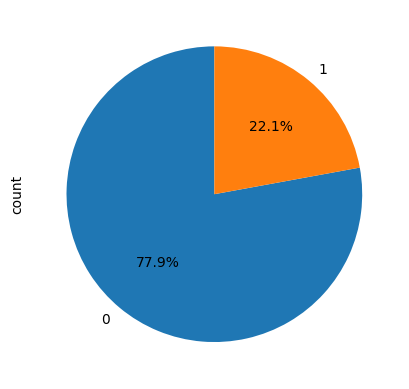

In [76]:
df['default payment next month'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)

In [77]:
df["EDUCATION"].value_counts().sort_index()

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Mentioned values in documentations are : <br>1 = graduate school; <br>2 = university;<br>3 = high school;<br>4 = others

   Although the dataset documentation specifies four education categories, exploratory analysis revealed additional values
(0, 5, and 6). These values represent rare or undocumented education categories commonly observed in real-world financial datasets. To ensure data consistency and meaningful interpretation, these values were grouped under the “Others” category, following standard practices in credit risk modeling literature. This transformation reduces noise, improves model stability, and supports reliable fairness analysis.

In [78]:
df['EDUCATION'].replace({0:4, 5:4, 6:4}, inplace=True)
df["EDUCATION"].value_counts().sort_index()

C:\Users\mohit\AppData\Local\Temp\ipykernel_25068\2926220841.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['EDUCATION'].replace({0:4, 5:4, 6:4}, inplace=True)


EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

In [79]:
df["MARRIAGE"].value_counts().sort_index()

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

Official documentation:

1 = Married<br>
2 = Single<br>
3 = Others<br>

The marital status attribute contained an additional category (value 0) not specified in the original dataset documentation. This value represents an unknown or unreported marital status. Given the small number of observations in this category, it was merged into the “Others” class to ensure data consistency and reliable statistical analysis. This preprocessing step aligns with standard practices in credit risk modeling and supports robust fairness evaluation.

In [80]:
df['MARRIAGE'].replace({0:3}, inplace=True)
df["MARRIAGE"].value_counts().sort_index()

C:\Users\mohit\AppData\Local\Temp\ipykernel_25068\1718954285.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MARRIAGE'].replace({0:3}, inplace=True)


MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

In [81]:
df['SEX'].value_counts().sort_index()

SEX
1    11888
2    18112
Name: count, dtype: int64

GENDER <br>

1: Male<br>
2: Female

==========================================================================================================================

In [82]:
df['AGE'].describe()

count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64

====================================================================================================================================

The variable group (X6–X11 / PAY_0–PAY_6) is the most important predictive signal. They represent severity and not just numbers. And these are ordinal variables(ordered categories).<br>

  Given : <br>

| Column Name | The Repayment status in |
| ----------  | ----------------------- |
| **PAY_0**   | September               |
| **PAY_2**   | August                  |
| **PAY_3**   | July                    |
| **PAY_4**   | June                    |
| **PAY_5**   | May                     |
| **PAY_6**   | April                   |

<br>

Following table denotes the measurement scale for the repayment status as given: <br>


| Value  | Meaning                    |
| ------ | ---------------------------|
| **-1** | Paid duly (no delay)       |
| **0**  | No consumption / no delay  |
| **1**  | 1 month delay              |
| **2**  | 2 months delay             |
| ...    | ...                        |
| **8**  | 8 months delay             |
| **9**  | 9 or 9+ months delay       |


In [83]:
pay_rename_map = {
    'PAY_0': 'PAY_SEPT',
    'PAY_2': 'PAY_AUG',
    'PAY_3': 'PAY_JUL',
    'PAY_4': 'PAY_JUN',
    'PAY_5': 'PAY_MAY',
    'PAY_6': 'PAY_APR'
}

df.rename(columns=pay_rename_map, inplace=True)

In [84]:

df[list(pay_rename_map.values())].value_counts()

PAY_SEPT  PAY_AUG  PAY_JUL  PAY_JUN  PAY_MAY  PAY_APR
 0         0        0        0        0        0         9821
-2        -2       -2       -2       -2       -2         2109
-1        -1       -1       -1       -1       -1         1992
 1        -2       -2       -2       -2       -2          651
 2         2        2        2        2        2          530
                                                         ... 
 4         4        3        2        3        2            1
                                      2        3            1
                                               0            1
           3        4        4        4        3            1
                    3        3        2        2            1
Name: count, Length: 1106, dtype: int64

As given all 0 and -ve integer signifies no delay and hence converting negative integers with 0.

In [85]:
#Negative values are being replaced from 0
df[list(pay_rename_map.values())] = (
    df[list(pay_rename_map.values())]
    .clip(lower=0))
df[list(pay_rename_map.values())].value_counts()


PAY_SEPT  PAY_AUG  PAY_JUL  PAY_JUN  PAY_MAY  PAY_APR
0         0        0        0        0        0          19931
1         0        0        0        0        0           1666
2         0        0        0        0        0            703
0         0        2        0        0        0            650
1         2        0        0        0        0            626
                                                         ...  
4         3        4        4        4        3              1
                   3        3        2        2              1
                            2        3        2              1
0         0        0        0        3        3              1
4         4        4        5        4        3              1
Name: count, Length: 402, dtype: int64

In [86]:
df['PAY_APR'].value_counts().sort_index()

PAY_APR
0    26921
2     2766
3      184
4       49
5       13
6       19
7       46
8        2
Name: count, dtype: int64

In [87]:
df['PAY_JUN'].value_counts().sort_index()

PAY_JUN
0    26490
1        2
2     3159
3      180
4       69
5       35
6        5
7       58
8        2
Name: count, dtype: int64

In [88]:
bill_rename_map = {
    'BILL_AMT1': 'BILL_SEPT',
    'BILL_AMT2': 'BILL_AUG',
    'BILL_AMT3': 'BILL_JUL',
    'BILL_AMT4': 'BILL_JUN',
    'BILL_AMT5': 'BILL_MAY',
    'BILL_AMT6': 'BILL_APR'
}

df.rename(columns=bill_rename_map, inplace=True)

pay_amt_rename_map = {
    'PAY_AMT1': 'PAY_AMT_SEPT',
    'PAY_AMT2': 'PAY_AMT_AUG',
    'PAY_AMT3': 'PAY_AMT_JUL',
    'PAY_AMT4': 'PAY_AMT_JUN',
    'PAY_AMT5': 'PAY_AMT_MAY',
    'PAY_AMT6': 'PAY_AMT_APR'
}

df.rename(columns=pay_amt_rename_map, inplace=True)



In [89]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_SEPT',
       'PAY_AUG', 'PAY_JUL', 'PAY_JUN', 'PAY_MAY', 'PAY_APR', 'BILL_SEPT',
       'BILL_AUG', 'BILL_JUL', 'BILL_JUN', 'BILL_MAY', 'BILL_APR',
       'PAY_AMT_SEPT', 'PAY_AMT_AUG', 'PAY_AMT_JUL', 'PAY_AMT_JUN',
       'PAY_AMT_MAY', 'PAY_AMT_APR', 'default payment next month'],
      dtype='object')

For improved interpretability and consistency with the dataset description, the repayment status, bill amount, and payment amount variables were renamed to reflect their corresponding calendar months. This renaming enhances readability in exploratory analysis, model interpretation, and SHAP-based explanations, without altering the underlying data semantics.

===================================================================================================================================<br>

### Feature Engineering

X12-X17: Bill statements

In [90]:
pay_cols = ['PAY_SEPT','PAY_AUG','PAY_JUL','PAY_JUN','PAY_MAY','PAY_APR']



a) Maximum delay in last 6 months (Worst repayment behaviour which can help capture risk)

In [91]:
df['MAX_DELAY'] = df[pay_cols].max(axis=1)


b) Average Delay

In [92]:
df['AVG_DELAY'] = df[pay_cols].mean(axis=1)

c) Count of delayed months (delay ≥ 1)

In [93]:
df['NUM_DELAYED_MONTHS'] = (df[pay_cols] >= 1).sum(axis=1)

d) Severe delay indicator (≥ 3 months)

In [94]:
df['SEVERE_DELAY_FLAG'] = (df[pay_cols] >= 3).any(axis=1).astype(int)

-The repayment status variables represent ordinal measures of payment delay over the previous six months. These variables were retained in their original numeric form to preserve the inherent ordering information.  <br>
In addition, summary features such as maximum delay, average delay, and number of delayed months were derived to capture overall repayment behavior trends. This approach preserves interpretability while enhancing predictive performance.<br>


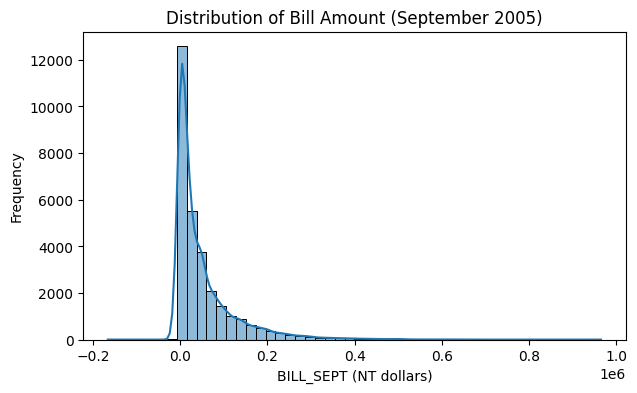

In [95]:
plt.figure(figsize=(7,4))
sns.histplot(df['BILL_SEPT'], bins=50, kde=True)
plt.title("Distribution of Bill Amount (September 2005)")
plt.xlabel("BILL_SEPT (NT dollars)")
plt.ylabel("Frequency")
plt.show()


In [96]:
bill_cols = ['BILL_SEPT','BILL_AUG','BILL_JUL','BILL_JUN','BILL_MAY','BILL_APR']
df[bill_cols].describe()



,BILL_SEPT,BILL_AUG,BILL_JUL,BILL_JUN,BILL_MAY,BILL_APR
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400
std,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000
50%,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000
75%,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


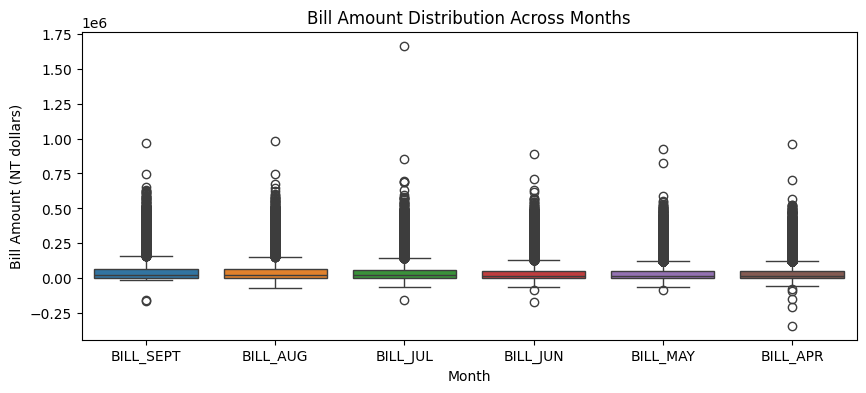

In [97]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df[bill_cols])
plt.title("Bill Amount Distribution Across Months")
plt.xlabel("Month")
plt.ylabel("Bill Amount (NT dollars)")
plt.show()

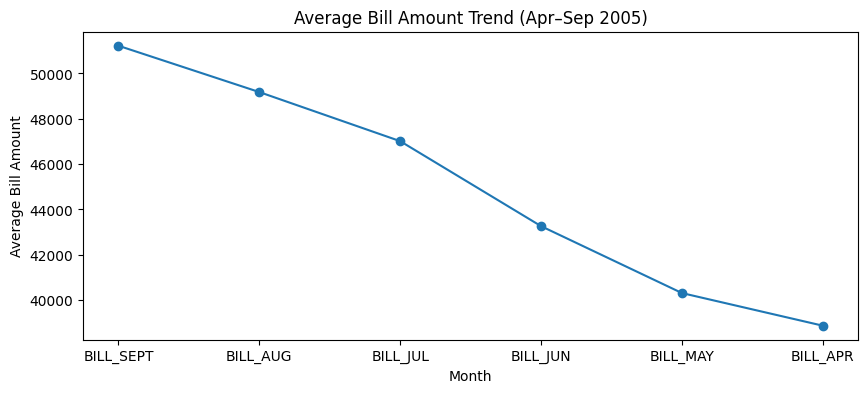

In [98]:
avg_bill = df[bill_cols].mean()
plt.figure(figsize=(10,4))
avg_bill.plot(marker='o')
plt.title("Average Bill Amount Trend (Apr–Sep 2005)")
plt.xlabel("Month")
plt.ylabel("Average Bill Amount")
plt.show()


a) Average Bill Amount

In [99]:

df['AVG_BILL_AMT'] = df[bill_cols].mean(axis=1)

b) Maximum bill amount

In [100]:

df['MAX_BILL_AMT'] = df[bill_cols].max(axis=1)


c) Bill trend 

In [101]:
df['NET_BILL'] = df['BILL_SEPT'] - df['BILL_APR']

Interpretation:

Positive -> increasing usage <br>
Negative -> decreasing usage

These <bill_cols> are Bill Statement Amounts. These are temporal variables which represents information across time i.e.,<br>
 X12–X17 are Bills from April → September 2005 <br>
Each column is one snapshot in time but together, they form a sequence. Also they are :

-Continuous money values<br>
-Highly right-skewed (which means few are high spenders but mostly low spenders)<br>
-Strongly correlated across months<br>
-Capture credit usage intensity

   Hence instead of looking at each month separately, we can:<br>
Summarize trends (increasing/decreasing)<br>
Capture overall behavior

====================================================================================================================================<br>
X18–X23 (Previous Payment Amounts)


In [102]:
pay_amt_cols = ['PAY_AMT_SEPT','PAY_AMT_AUG','PAY_AMT_JUL','PAY_AMT_JUN','PAY_AMT_MAY','PAY_AMT_APR']
df[pay_amt_cols].describe()

,PAY_AMT_SEPT,PAY_AMT_AUG,PAY_AMT_JUL,PAY_AMT_JUN,PAY_AMT_MAY,PAY_AMT_APR
count,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


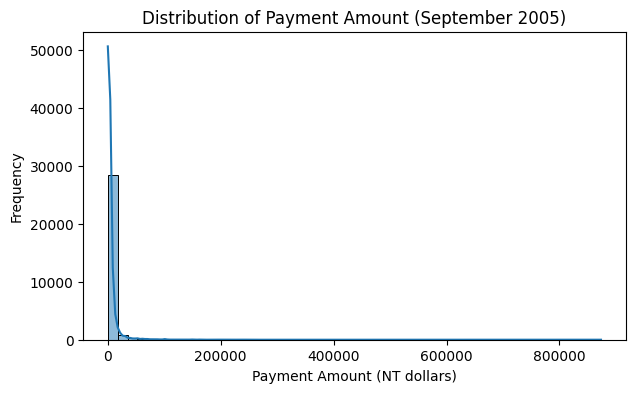

In [103]:
plt.figure(figsize=(7,4))
sns.histplot(df['PAY_AMT_SEPT'], bins=50, kde=True)
plt.title("Distribution of Payment Amount (September 2005)")
plt.xlabel("Payment Amount (NT dollars)")
plt.ylabel("Frequency")
plt.show()


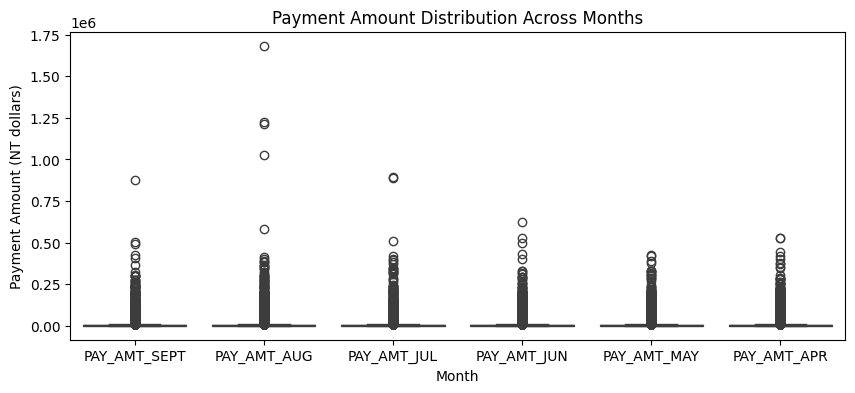

In [104]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df[pay_amt_cols])
plt.title("Payment Amount Distribution Across Months")
plt.xlabel("Month")
plt.ylabel("Payment Amount (NT dollars)")
plt.show()

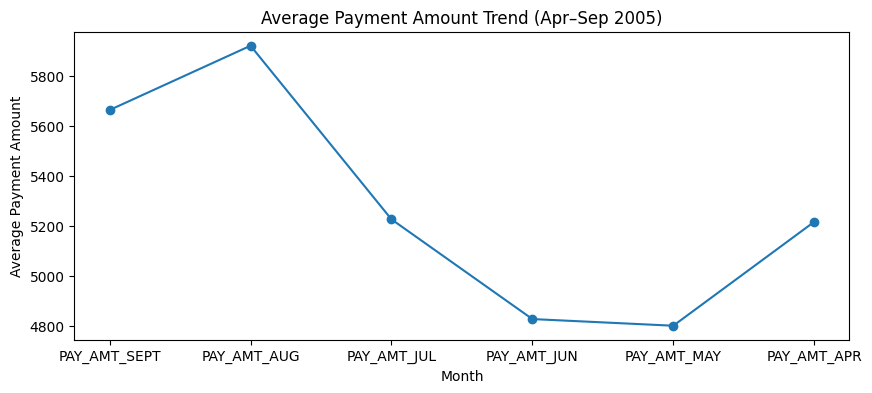

In [105]:
avg_payment = df[pay_amt_cols].mean()

plt.figure(figsize=(10,4))
avg_payment.plot(marker='o')
plt.title("Average Payment Amount Trend (Apr–Sep 2005)")
plt.xlabel("Month")
plt.ylabel("Average Payment Amount")
plt.show()


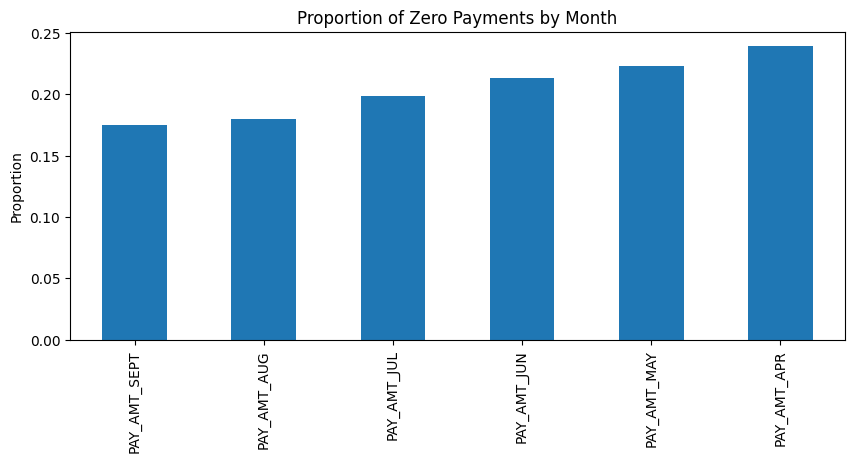

In [106]:
zero_payment_ratio = (df[pay_amt_cols] == 0).mean()

plt.figure(figsize=(10,4))
zero_payment_ratio.plot(kind='bar')
plt.title("Proportion of Zero Payments by Month")
plt.ylabel("Proportion")
plt.show()


a) Average Payment

In [107]:
df['AVG_PAY_AMT'] = df[pay_amt_cols].mean(axis=1)


b) Total payment

In [108]:

df['TOTAL_PAY_AMT'] = df[pay_amt_cols].sum(axis=1)

c) Payment-to-bill ratio

In [109]:
df['PAY_TO_BILL_RATIO'] = (df[pay_amt_cols].sum(axis=1) / (df[bill_cols].sum(axis=1) + 1)
)


One added in denominator to prevent division by zero in cases where customers had zero or negative bill amounts. Since bill values are large, adding one will ensure numerical stability without affecting meaningful ratios.

Interpretation:

Close to 1   -> Responsible repayment behaviour  <br>
More than 1  -> Overpayment or credit balance, indicating low default risk   <br>
Low Value (<< 1)   -> Underpayment behaviour, indicating higher default risk <br>
Negative value   -> Typically indicates overpayment or refunds, generally associated with low default risk. <br>

This feature indicates crucial insight when it comes to **Explainability**.

Also this is a pure Customer behavioural indicator. Behavioural features are:

-Fairer than demographics <br>
-More relevant for decision-making <br>
-Less ethically sensitive

The billing amount and previous payment variables represent continuous financial behavior over a six-month period. These features were retained in their original numeric form, as tree-based models effectively handle skewed monetary distributions. To capture overall spending and repayment behavior, additional summary features such as average bill amount, maximum bill amount, total payments, and payment-to-bill ratio were derived. This approach enhances interpretability and predictive robustness while preserving the original temporal information.<br>

=============================================================================================

a) Credit Limit - LIMIT_BAL <br>
Core financial capacity indicator

b) Repayment Behavior (Ordinal) - PAY_SEPT, PAY_AUG, PAY_JUL, PAY_JUN, PAY_MAY, PAY_APR
 Derived the following from this: MAX_DELAY, AVG_DELAY, NUM_DELAYED_MONTHS, SEVERE_DELAY_FLAG

c) Billing Behavior (Continuous, Temporal) - BILL_SEPT, BILL_AUG, BILL_JUL, BILL_JUN, BILL_MAY, BILL_APR
Derived the following from this: AVG_BILL_AMT, MAX_BILL_AMT

d) Payment Behavior (Continuous, Behavioral) - PAY_AMT_SEPT, PAY_AMT_AUG, PAY_AMT_JUL, PAY_AMT_JUN, PAY_AMT_MAY, PAY_AMT_APR
Derived the following from this : AVG_PAY_AMT, TOTAL_PAY_AMT, PAY_TO_BILL_RATIO


===================================================================================================================================


In [110]:
df = df.drop(columns=['ID'])

Dropped ID as it is only a unique identifier for each customer and contributes nothing with respect to behavioural or financial meaning.

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  int64  
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_SEPT                    30000 non-null  int64  
 6   PAY_AUG                     30000 non-null  int64  
 7   PAY_JUL                     30000 non-null  int64  
 8   PAY_JUN                     30000 non-null  int64  
 9   PAY_MAY                     30000 non-null  int64  
 10  PAY_APR                     30000 non-null  int64  
 11  BILL_SEPT                   30000 non-null  int64  
 12  BILL_AUG                    30000 non-null  int64  
 13  BILL_JUL                    300

In [112]:
X = df.drop(columns=['default payment next month'])
y = df['default payment next month']   # y -> target variable

In [113]:
y.value_counts(normalize=True)*100

default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64

1 -> Yes <br>
0 -> No

Since, **y** is highly imbalanced, hence **Accuracy** alone will be misleading. 

In [114]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [115]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [116]:
print(f"y_train:\n{y_train.value_counts(normalize=True)} ")
print('============================================')
print(f"y_test:\n{y_test.value_counts(normalize=True)}")


y_train:
default payment next month
0    0.778792
1    0.221208
Name: proportion, dtype: float64 
y_test:
default payment next month
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In [117]:
print(f"X_train:\n{X_train['SEX'].value_counts(normalize=True)} ")
print('============================================')
print(f"X_test:\n{X_test['SEX'].value_counts(normalize=True)}")



X_train:
SEX
2    0.60475
1    0.39525
Name: proportion, dtype: float64 
X_test:
SEX
2    0.599667
1    0.400333
Name: proportion, dtype: float64


After exploratory analysis and feature engineering, the final feature set was organized into demographic, repayment behavior, billing behavior, and payment behavior groups. Sensitive attributes such as gender and age were retained to enable fairness evaluation. Age was discretized into categorical groups to facilitate group-wise bias analysis.

The dataset was divided into training and testing sets using a stratified split to preserve the original class imbalance. This approach ensures reliable performance evaluation and unbiased fairness assessment. No scaling was applied for tree-based models, as these models are invariant to monotonic transformations of features.

In [213]:
# Model 1: Logistic Regression (with scaling)

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))



Logistic Regression Results
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      4673
           1       0.44      0.59      0.50      1327

    accuracy                           0.74      6000
   macro avg       0.65      0.69      0.66      6000
weighted avg       0.77      0.74      0.75      6000

ROC-AUC: 0.7448452049654003


In [212]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))



Random Forest Results
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.64      0.34      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC: 0.757880775756317


In [211]:

from sklearn.metrics import precision_recall_curve

y_probs = lr_pipeline.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

custom_threshold = 0.3
y_pred_custom = (y_probs >= custom_threshold).astype(int)

from sklearn.metrics import classification_report
print("Logistic Regression Results after threshold tuning")
print(classification_report(y_test, y_pred_custom))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))



Logistic Regression Results after threshold tuning
              precision    recall  f1-score   support

           0       0.90      0.31      0.46      4673
           1       0.27      0.88      0.41      1327

    accuracy                           0.43      6000
   macro avg       0.58      0.60      0.43      6000
weighted avg       0.76      0.43      0.45      6000

ROC-AUC: 0.7448452049654003


In [210]:
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
print("XgBoost Results")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))




XgBoost Results
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4673
           1       0.47      0.57      0.51      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.76      0.77      6000

ROC-AUC: 0.7553660488647849


In [209]:
from imblearn.ensemble import BalancedRandomForestClassifier

brf = BalancedRandomForestClassifier(
    n_estimators=300,
    random_state=42
)
brf.fit(X_train, y_train)
y_pred_brf = brf.predict(X_test)
y_prob_brf = brf.predict_proba(X_test)[:, 1]
print("BRF Results")
print(classification_report(y_test, y_pred_brf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_brf))


BRF Results
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      4673
           1       0.50      0.56      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000

ROC-AUC: 0.7660812946666793


## FAIRNESS-SAFE SPLIT 

#### Fairness Metrics require categorical groups. For df['Sex'] we have Male and Female. Raw Age is a continous variable. Hence, discretizing it into the following :

In [142]:
protected = 'SEX'
privileged = [{'SEX': 1}]
unprivileged = [{'SEX': 2}]


In [143]:
df_fairness = df.copy()

In [144]:
df_fairness['AGE_GROUP'] = pd.cut(
    df_fairness['AGE'],
    bins=[20, 35, 60, 80],
    labels=[0, 1, 2]
)
df_fairness['AGE_GROUP'].value_counts(normalize=True)*100

AGE_GROUP
0    56.030000
1    43.063333
2     0.906667
Name: proportion, dtype: float64

0 - Young <br>
1 - Middle <br>
2 - Senior

Demographic / Sensitive Attributes :
Used for fairness evaluation

| Feature   |  Role             |
| --------- | ----------        |
| SEX       | Protected         |
| AGE_GROUP | Protected         |



In [145]:
df_fairness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   LIMIT_BAL                   30000 non-null  int64   
 1   SEX                         30000 non-null  int64   
 2   EDUCATION                   30000 non-null  int64   
 3   MARRIAGE                    30000 non-null  int64   
 4   AGE                         30000 non-null  int64   
 5   PAY_SEPT                    30000 non-null  int64   
 6   PAY_AUG                     30000 non-null  int64   
 7   PAY_JUL                     30000 non-null  int64   
 8   PAY_JUN                     30000 non-null  int64   
 9   PAY_MAY                     30000 non-null  int64   
 10  PAY_APR                     30000 non-null  int64   
 11  BILL_SEPT                   30000 non-null  int64   
 12  BILL_AUG                    30000 non-null  int64   
 13  BILL_JUL        

In [146]:
protected = 'AGE_GROUP'
privileged = [{'AGE_GROUP': 0}]
unprivileged = [{'AGE_GROUP': 1}]



In [147]:
protected = 'AGE_GROUP'
privileged = [{'AGE_GROUP': 1}]
unprivileged = [{'AGE_GROUP': 2}]


In [148]:
%pip install aif360[all]

Note: you may need to restart the kernel to use updated packages.


In [149]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric

def run_bias_audit(df, label, protected_attr, privileged, unprivileged):
    aif_data = BinaryLabelDataset(
        df=df_fairness,
        label_names=[label],
        protected_attribute_names=[protected_attr],
        favorable_label=0,
        unfavorable_label=1
    )
    
    metric = BinaryLabelDatasetMetric(
        aif_data,
        privileged_groups=privileged,
        unprivileged_groups=unprivileged
    )
    
    spd = float(metric.statistical_parity_difference())
    di  = float(metric.disparate_impact())
    
    return spd, di

        



In [150]:
SPD_sex , DI_sex = run_bias_audit(df_fairness, 'default payment next month', 'SEX',
                           [{'SEX':1}], [{'SEX':2}])

SPD_age , DI_age = run_bias_audit(df_fairness, 'default payment next month', 'AGE_GROUP',
                           [{'AGE_GROUP':1}], [{'AGE_GROUP':0}])

SPD_age1 , DI_age1 = run_bias_audit(df_fairness, 'default payment next month', 'AGE_GROUP',
                                [{'AGE_GROUP':1}], [{'AGE_GROUP':2}])

print(f"Sex\n SPD: {SPD_sex} , DI: {DI_sex}\n")
print(f"Age_Group(M vs Y)\n SPD: {SPD_age} , DI: {DI_age}\n")
print(f"Age_Group(M vs S)\n SPD: {SPD_age1} , DI: {DI_age1}")


Sex
 SPD: 0.033909465375304926 , DI: 1.0447161091937465

Age_Group(M vs Y)
 SPD: 0.015591829137014845 , DI: 1.0202382036191193

Age_Group(M vs S)
 SPD: -0.03879801978845576 , DI: 0.9496401469258455


The dataset is already fairly balanced at the label level as shown above.

| Attribute        | Bias Level | 
| ---------------- | ---------- | 
| **SEX**          | Negligible | 
| **AGE (M vs Y)** | Negligible | 
| **AGE (M vs S)** | Mild       | 

A pre-training bias audit was conducted across gender and age groups using Statistical Parity Difference and Disparate Impact metrics. The analysis revealed minimal disparity across gender and age categories, indicating that the dataset does not exhibit significant historical bias at the label level. Minor disparities were observed for senior customers; however, these remained within acceptable thresholds. Despite the relatively fair nature of the dataset, fairness mitigation was applied as a preventive measure to ensure that downstream models do not introduce unintended bias during training.


Reweighing is a pre-processing fairness mitigation technique that does not change feature values and labels but adjusts instance weights so that:

-Privileged and unprivileged groups are treated more equally<br>
-The learner “pays more attention” to underrepresented outcomes

This is ideal for this as pre-training bias is low and we want preventive fairness, not aggressive correction. Besides, it preserves explainability as well.<br>

 Example : Fairness Mitigation using Reweighing (SEX only)


In [169]:
from aif360.algorithms.preprocessing import Reweighing

# Combine X_train and y_train
train_df = X_train.copy()
train_df['default payment next month'] = y_train.values

# Create BinaryLabelDataset
aif_train = BinaryLabelDataset(
    df=train_df,
    label_names=['default payment next month'],
    protected_attribute_names=['SEX'],
    favorable_label=0,
    unfavorable_label=1
)

In [170]:
# Apply Reweighing

privileged_groups = [{'SEX': 1}]
unprivileged_groups = [{'SEX': 2}]

reweigher = Reweighing(
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

aif_train_rw = reweigher.fit_transform(aif_train)


Train Logistic Regression using reweighted samples. <br>
We now retrain Logistic Regression, passing sample_weight.

In [171]:
X_train_rw = aif_train_rw.features
y_train_rw = aif_train_rw.labels.ravel()
sample_weights = aif_train_rw.instance_weights


In [172]:
lr_rw = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

lr_rw.fit(X_train_rw, y_train_rw, lr__sample_weight=sample_weights)

,steps,"[('scaler', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


Evaluation of performance with same test set as above.

In [208]:
y_pred_rw = lr_rw.predict(X_test)
y_prob_rw = lr_rw.predict_proba(X_test)[:, 1]


print(classification_report(y_test, y_pred_rw))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rw))



              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

ROC-AUC: 0.7417734775170288


C:\Users\mohit\miniconda3\envs\pytorch_env\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\mohit\miniconda3\envs\pytorch_env\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


It also has very similar performance with possibly slight recall/precision shift. 

----------------------------------------------------------------------------------------------------------- <br>
Post training fairness audit

In [182]:
from aif360.metrics import ClassificationMetric

# Test set with predictions
test_df = X_test.copy()
test_df['default payment next month'] = y_test.values
test_df['pred'] = y_pred_rw

aif_test = BinaryLabelDataset(
    df=test_df.drop(columns=['pred']),
    label_names=['default payment next month'],
    protected_attribute_names=['SEX'],
    favorable_label=0,
    unfavorable_label=1
)

aif_test_pred = aif_test.copy()
aif_test_pred.labels = y_pred_rw.reshape(-1, 1)


In [184]:
metric_post = ClassificationMetric(
    aif_test,
    aif_test_pred,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

print("Post-Mitigation SPD:", metric_post.statistical_parity_difference())
print("Post-Mitigation DI :", metric_post.disparate_impact())


Post-Mitigation SPD: -0.00155743846960954
Post-Mitigation DI : 0.9982287087102263


Pre-training bias was already low:

| Metric   | Before   | After               |
| -------- | -------- | ------------------- |
| SPD      | ≈ 0.008  | closer to 0 (-0.001) |
| DI       | ≈ 1.010  | closer to 1 (0.998) |

The application of Reweighing on 'SEX' attribute resulted in negligible performance degradation, confirming that the mitigation strategy is non-destructive when the initial bias is low.

In [185]:
%pip install shap



  Using cached numpy-2.4.2-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.3.5-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.3.5-cp311-cp311-win_amd64.whl (13.1 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy None
Note: you may need to restart the kernel to use updated packages.


error: uninstall-no-record-file

× Cannot uninstall numpy None
╰─> The package's contents are unknown: no RECORD file was found for numpy.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps numpy==1.26.4


C:\Users\mohit\miniconda3\envs\pytorch_env\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


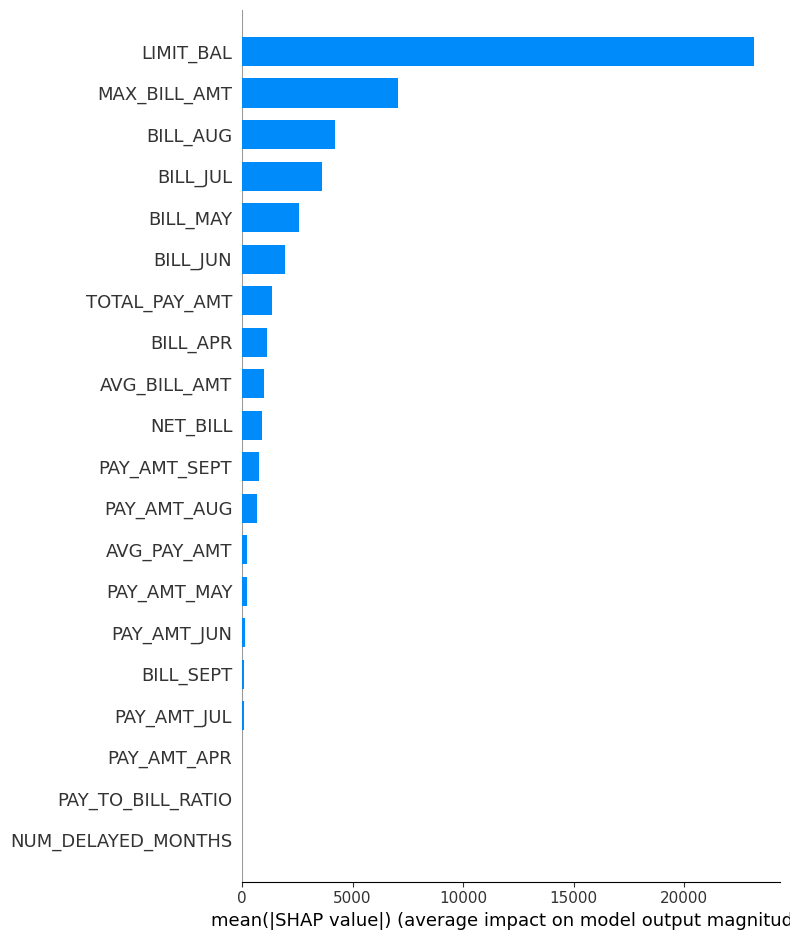

In [186]:
import shap

X_train_shap = X_train.copy()
X_test_shap = X_test.copy()

explainer = shap.LinearExplainer(
    lr_pipeline.named_steps['lr'],
    X_train_shap,
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_test_shap)
shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar"
)


SHAP values = contribution of each feature.

This shows :-

Average absolute impact of each feature on model predictions

Higher bar = more influence on decisions (regardless of direction)<br>


**Key observations :**

1. **LIMIT_BAL** is the most influential feature. It shows that- <br>
Credit limit reflects financial capacity<br>
Lower limits => higher default risk

2. **Billing-related features dominate next**<br>
MAX_BILL_AMT<br>
BILL_JUL, BILL_AUG, BILL_MAY, BILL_JUN<br>
AVG_BILL_AMT<br>

This indicates that the model relies heavily on spending behavior, which is financially intuitive.

3. **Payment features have moderate impact**<br>
TOTAL_PAY_AMT<br>
PAY_AMT_*

4. **Behavioral ratios and aggregates**<br>
PAY_TO_BILL_RATIO<br>
NET_BILL<br>
AVG_PAY_AMT<br>

These contribute, but are not dominating.

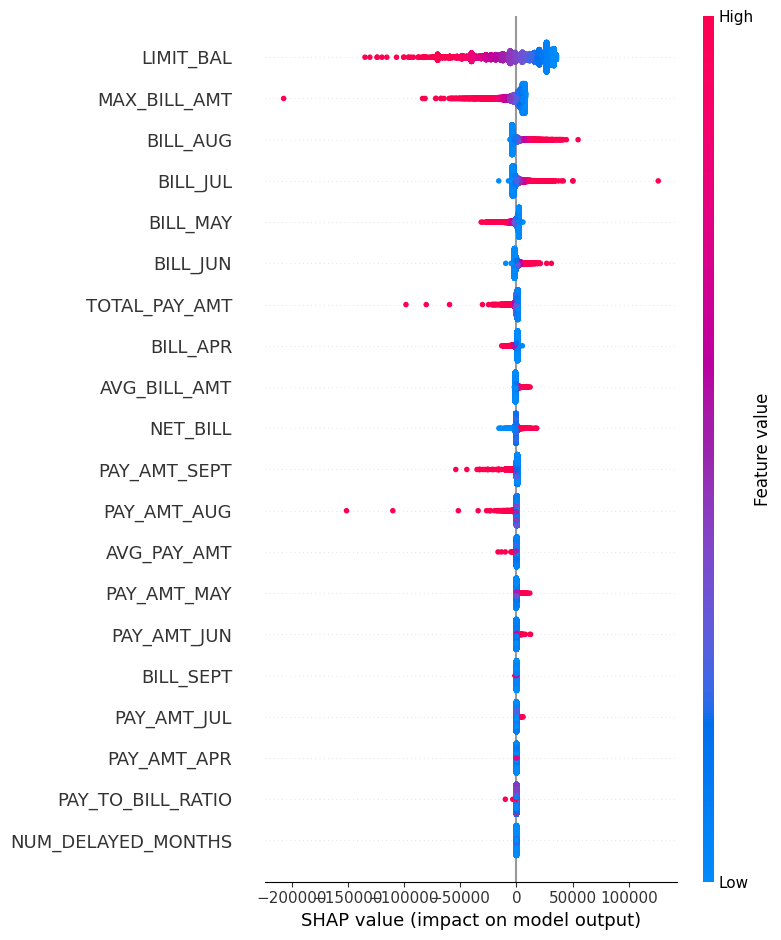

In [187]:
# SHAP Beeswarm plot

shap.summary_plot(
    shap_values,
    X_test_shap
)


**SHAP Beeswarm Plot**

This is the most important explainability plot.

X-axis: impact on default prediction<br>
Right → increases default risk<br>
Left → decreases default risk

Color:

 Red = high feature value<br>
 Blue = low feature value

Feature-wise interpretation <br>
1.**LIMIT_BAL**

 High LIMIT_BAL → negative SHAP values (left)<br>
 Low LIMIT_BAL → positive SHAP values (right)

 Interpretation: Customers with lower credit limits are more likely to default.

2.**MAX_BILL_AMT / Monthly BILL_ features**

 High bill amounts → push prediction toward default<br>
 Low bill amounts → reduce default risk<br>

 Interpretation: Higher outstanding bills increase default risk.

3.**TOTAL_PAY_AMT / PAY_AMT_***

 High payments → reduce default risk<br>
 Low payments → increase default risk

 Interpretation: Customers who consistently pay more are less likely to default.

4.**PAY_TO_BILL_RATIO**

Low ratio → pushes toward default<br>
High ratio → pushes away from default

 Interpretation: Paying a smaller fraction of the bill is a strong risk indicator.

5.**Demographic features**<br>

They are absent or negligible in top SHAP contributors

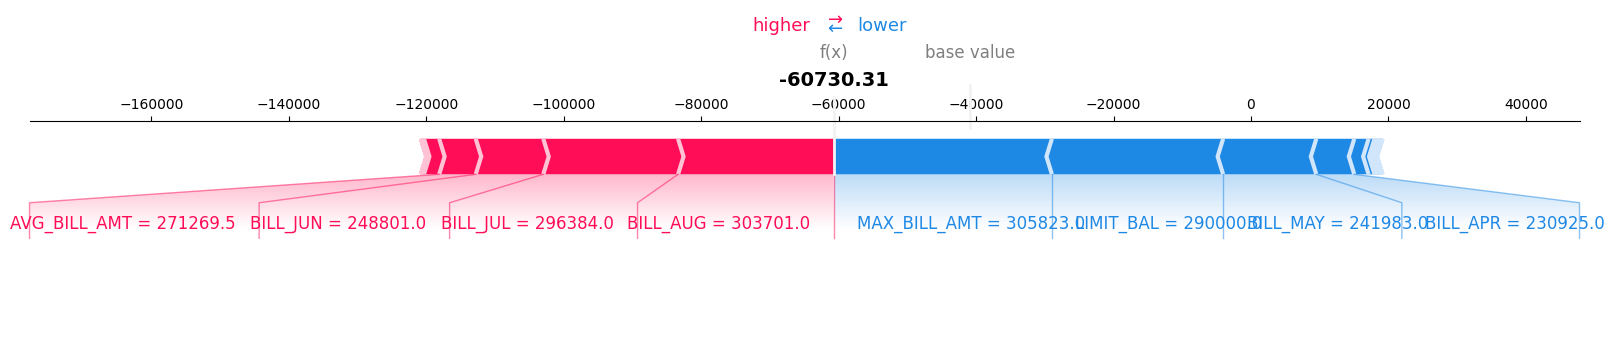

In [188]:
idx = np.where(y_test == 1)[0][0]

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_shap.iloc[idx],
    matplotlib=True
)



SHAP Force Plot (Local Explanation)

This plot explains one individual prediction.

Base value = model’s baseline log-odds prediction

Red features → push prediction toward default

Blue features → push prediction away from default

From force plot:

In Red ->  Factors increasing default risk

LIMIT_BAL = 80,000 (relatively low)

MAX_BILL_AMT = 4927

BILL_MAY = 3728

In Blue - > Factors reducing default risk

Moderate bills in:

BILL_JUL

BILL_AUG

BILL_JUN

AVG_BILL_AMT not extremely high

Key takeaway

This customer is classified as risky mainly due to limited credit capacity and relatively high bill amounts, not due to demographic attributes.

### Fairness Mitigation (AIF360 – Reweighing)

In [198]:
protected_attr = 'SEX'

aif_train = BinaryLabelDataset(
    df=pd.concat([X_train, y_train], axis=1),
    label_names=['default payment next month'],
    protected_attribute_names=[protected_attr],
    favorable_label=0,
    unfavorable_label=1
)

aif_test = BinaryLabelDataset(
    df=pd.concat([X_test, y_test], axis=1),
    label_names=['default payment next month'],
    protected_attribute_names=[protected_attr],
    favorable_label=0,
    unfavorable_label=1
)


In [199]:
metric_pre = BinaryLabelDatasetMetric(
    aif_train,
    privileged_groups=[{protected_attr: 1}],
    unprivileged_groups=[{protected_attr: 2}]
)

print("Pre-mitigation Statistical Parity Difference:",
      metric_pre.statistical_parity_difference())

print("Pre-mitigation Disparate Impact:",
      metric_pre.disparate_impact())


Pre-mitigation Statistical Parity Difference: 0.037237313324472776
Pre-mitigation Disparate Impact: 1.0492379640641132


In [200]:
rw = Reweighing(
    privileged_groups=[{protected_attr: 1}],
    unprivileged_groups=[{protected_attr: 2}]
)

aif_train_rw = rw.fit_transform(aif_train)


In [207]:
y_pred_rw = lr_rw.predict(X_test)
y_proba_rw = lr_rw.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rw))

print("ROC-AUC:", roc_auc_score(y_test, y_proba_rw))



              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

ROC-AUC: 0.7417734775170288


C:\Users\mohit\miniconda3\envs\pytorch_env\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\mohit\miniconda3\envs\pytorch_env\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [202]:
aif_test_pred_rw = aif_test.copy()
aif_test_pred_rw.labels = y_pred_rw.reshape(-1, 1)

metric_post = ClassificationMetric(
    aif_test,
    aif_test_pred_rw,
    privileged_groups=[{protected_attr: 1}],
    unprivileged_groups=[{protected_attr: 2}]
)

print("Post-mitigation Statistical Parity Difference:",
      metric_post.statistical_parity_difference())

print("Post-mitigation Disparate Impact:",
      metric_post.disparate_impact())


Post-mitigation Statistical Parity Difference: -0.00155743846960954
Post-mitigation Disparate Impact: 0.9982287087102263


### Step 6 : Post-Mitigation SHAP & Final Results

In [203]:


explainer_rw = shap.LinearExplainer(
    lr_rw.named_steps['lr'],
    X_train,
    feature_perturbation="interventional"
)

shap_values_rw = explainer_rw.shap_values(X_test)


C:\Users\mohit\miniconda3\envs\pytorch_env\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


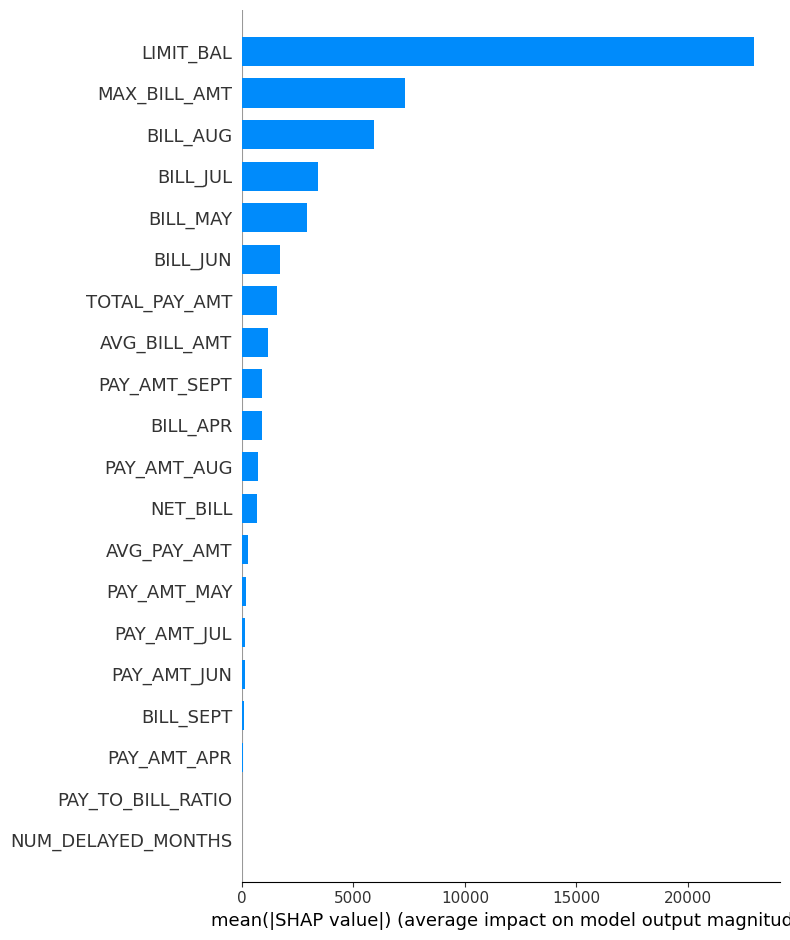

In [204]:
shap.summary_plot(
    shap_values_rw,
    X_test_shap,
    plot_type="bar"
)


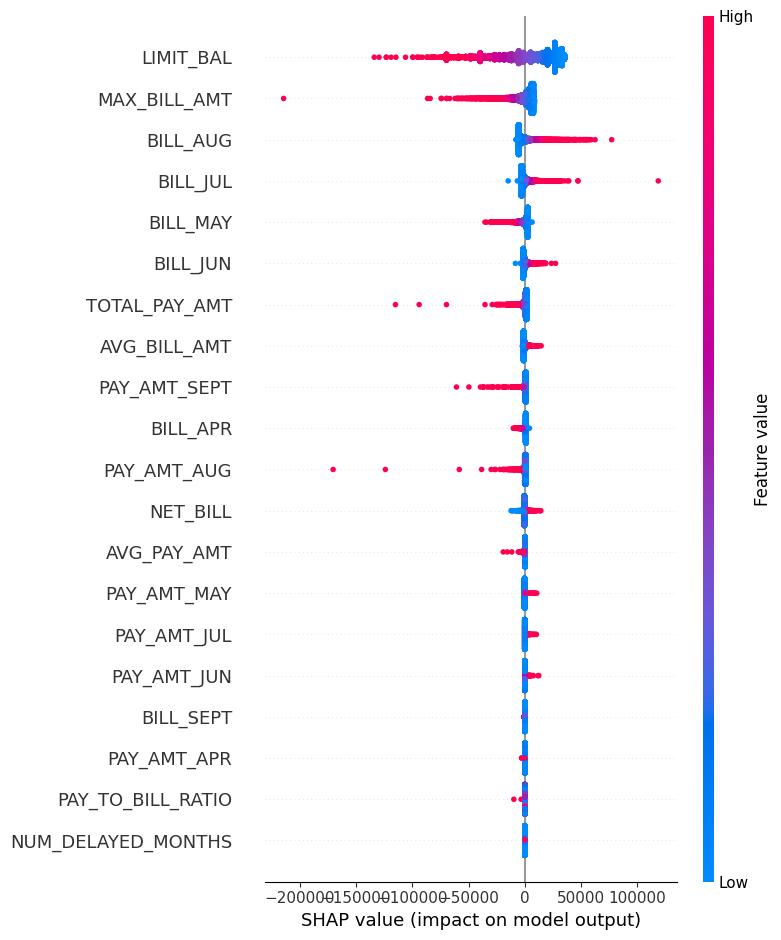

In [205]:
shap.summary_plot(
    shap_values_rw,
    X_test_shap
)


To evaluate the impact of fairness mitigation on model interpretability, SHAP analysis was repeated after applying reweighing. The post-mitigation SHAP results show that credit limit and billing behavior continue to dominate model predictions, with similar directional effects as observed before mitigation. Sensitive demographic attributes do not emerge as significant contributors. These findings indicate that reweighing improves fairness metrics without altering the financial rationale of the model, thereby preserving both interpretability and predictive validity.

In [206]:
import joblib

# Save trained Logistic Regression pipeline
joblib.dump(lr_pipeline, "model.joblib")

# Save SHAP explainer
joblib.dump(explainer_rw, "shap_explainer.joblib")

# Save feature names (list of columns in correct order)
joblib.dump(X_train.columns.tolist(), "feature_names.joblib")


['feature_names.joblib']